# 시작하기 앞서, Trouble Shooting  안내
### Q. 만약 잘 되던 코드가, 아래와 같은 에러메세지와 함께 동작이 안된다면?
```
AttributeError: module 'triton.backends' has no attribute 'compiler'
```

### A. 런타임 연결 해제 / 삭제 후 다시 실행해주세요.
- PyTorch랑 코랩 내부 엔진과 간헐적으로 버전 충돌 이슈가 있다고 합니다. (26.10.09 기준)
- 저는 연결 해제 > 3분 후 다시 실행 하니까 다시 잘 되었습니다.

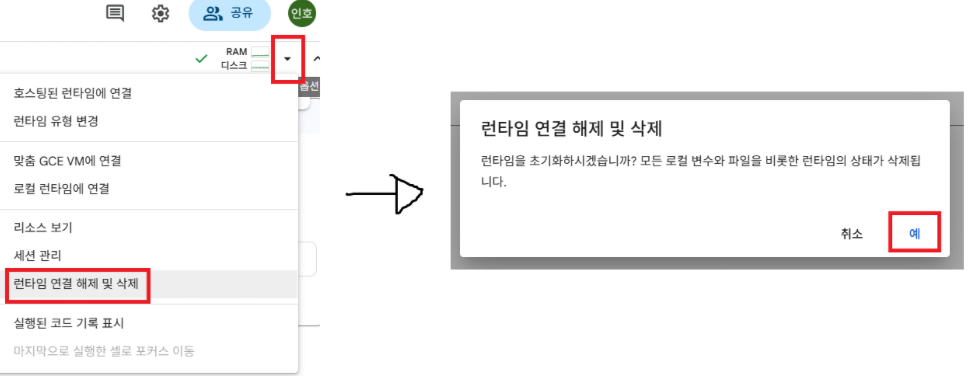

---

# 1. AI의 발전 과정
- 선형분류기 ---> 신경망 ---> 딥러닝 --> GPT


### 선형분류기
- 선형분류기는 y = ax + b 로 선을 그어서 분류하는 모델입니다.
- 선 위로는 A 클래스, 선 아래로는 B 클래스
- 아래 그림에서는 일부 오차는 있지만, 선형분류기는 잘 동작 할겁니다.

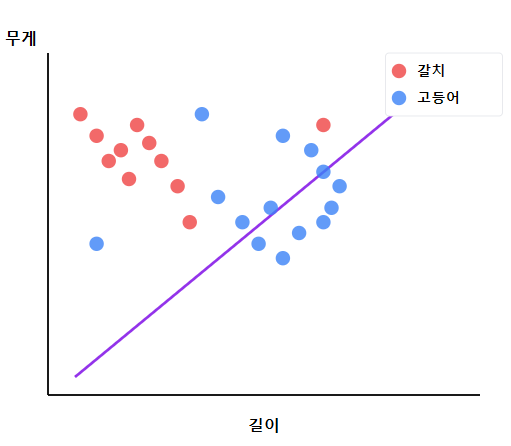

- 아래는 선형분류기 예시입니다.
  - 선 아래인 파란색에 속하면 고등어 입니다.
  - 선 위쪽인 빨간색에 속하면 갈치 입니다.

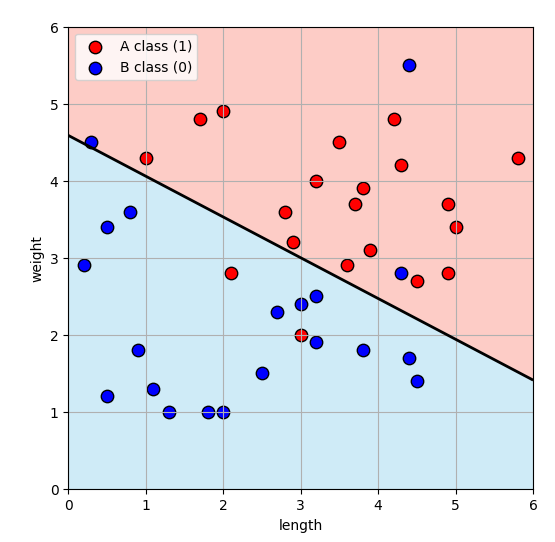

### XOR 문제
- XOR은 선형분류기로 분리를 할 수 없습니다.
- 마빈 민스키 박사님이 XOR 문제를 해결 못한다고 강조했고, AI에 겨울이 찾아왔습니다. (1970년)

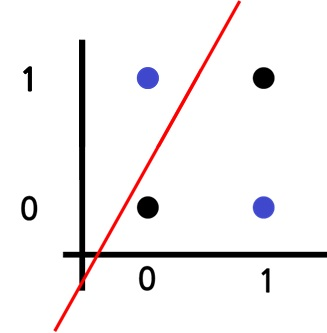

### 신경망(Neural Network) 등장
- XOR 문제를 풀려면, 선을 구부리면 됩니다.
  - 함수 중첩과 활성화 함수를 사용하면 비선형을 표현합니다.
  - 여기에 Gradient Decent 를 해서 XOR 문제를 해결했습니다. (1986년, 제프리 힌튼 교수님)
  - 수학적 원리는 이론강의를 참고합시다.

- 아래 수식에서 f() 는 활성화 함수를 표현했습니다.
  - 활성화 함수가 뭐고, 함수 중첩에 대한 자세한 내용은 조금 있다가 다룰겁니다.

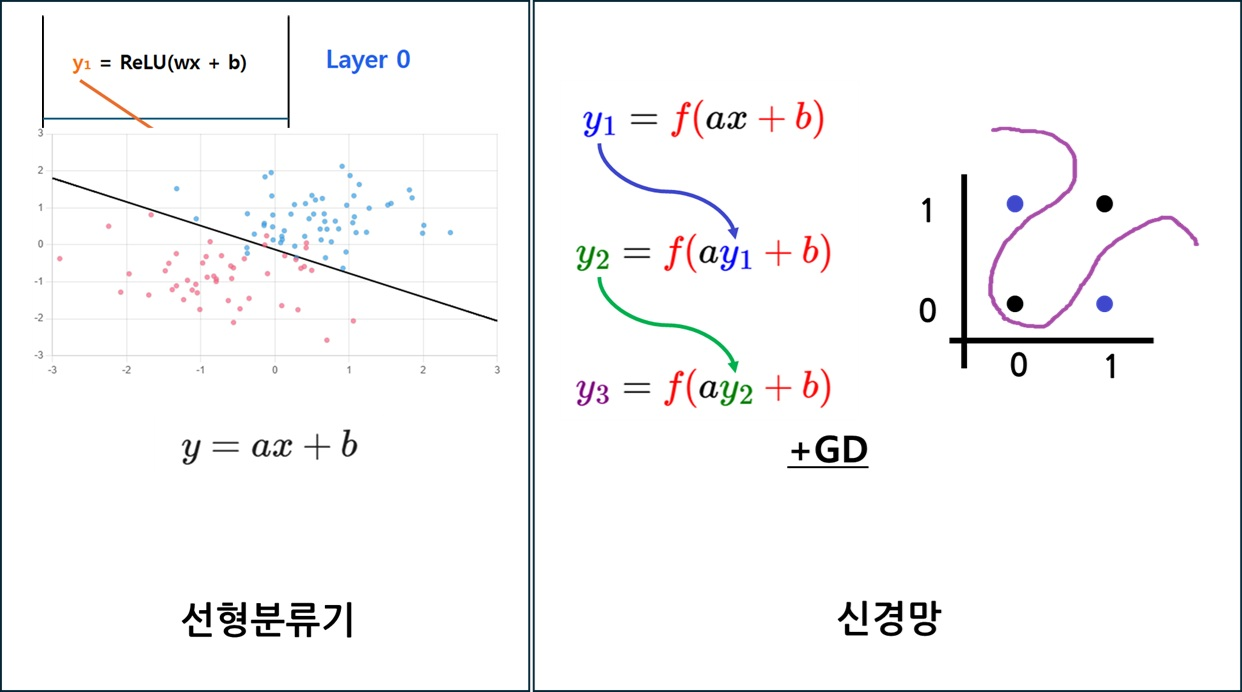

# 2. 이번 과정의 목표
- [선형분류기 > **신경망** > 딥러닝 > GPT] 순서로 AI가 발전되었다고  소개드렸는데요. 이번 챕터 주제는 신경망입니다.
- 신경망, 딥러닝 라이브러리인 Pytorch 라이브러리를 사용할겁니다.
  - 1. PyTorch를 소개하고
  - 2. 신경망(Neural Network, NN)을 다룹니다.
  - 3. 신경망으로 선형회귀, 로지스틱회귀를 만들어봅니다.
  - 4. 신경망 발전 역사에 대해 가볍게 알아봅니다.
  - 5. 신경망으로 숫자 분류기를 만들어봅니다. (MNIST 데이터셋 사용)

# 3. PyTorch 소개
- Deep Learning을 쉽게 구현하도록 만들어진 오픈소스 Library 입니다.
  - 예전에는 텐서플로우(구글개발)이 딥러닝 Library의 왕이 었습니다.
    - C++로 만들어졌고, 성능도 빨라요.
    - 개발자가 쓰기엔 괜찮은데, AI연구자가 쓰기엔 코딩 지식이 많이 필요해서 쓰기 힘들어요.
  - 그리고 PyTorch(메타 개발)와 여러가지 여러 딥러닝 라이브러리가 나왔습니다.
    - AI연구자들 사이에서 PyTorch 인기가 폭발했습니다.
    - 새로운 기능은 항상 텐서플로우가 먼저 개발되고, PyTorch가 조금 더 있다가 출시되었죠.
    - 당시 AI연구자들 사이에서도 텐서플로우 할줄알면 "올~ 쫌 하네?" 라는 분위기 였습니다
  - 현재는 PyTorch 인기가 텐서플로우 인기를 앞섰습니다.
    - 이제는 PyTorch나 텐서플로우나 새로운 기능은 거의 동시에 출시됩니다.
    - PyTorch는 텐서플로우보다 파이써닉합니다. (간결합니다.)
    - 디테일한 연산 과정과, 옵션들은 숨겨져 있습니다.
      - 마치 텐서플로우는 Spring MVC, PyTorch는 Spring Boot로 비유할수 있겠습니다.
  - 텐서플로우는 아직도 많이 쓰입니다.
    - AI 연구자에게 인기는 적어졌지만, 디테일한 옵션과 최적화를 해야하는 극단적인 세팅이 필요한 환경에서는 여전히 쓰입니다.
    - '왕'의 자리는 PyTorch에게 물려줬지만, 초 대규모 모델 개발시 or 초 소형 모델 개발시(임베디드 환경)에는 아직 필요합니다.



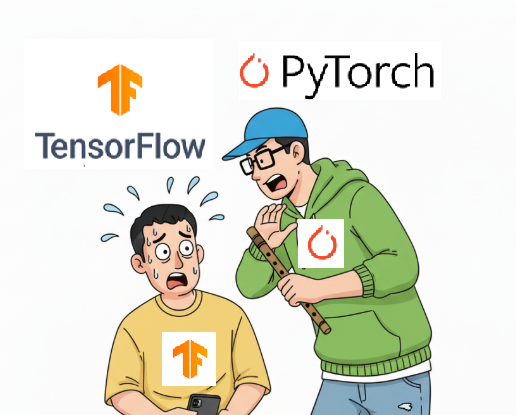

# 4. PyTorch 기본 사용법
- Numpy Array 대신 텐서(Tensor)를 사용합니다.
  - PyTorch Library에서는 벡터를 1차원 텐서라고 합니다.
  - PyTorch Library에서는 행렬을 2차원 텐서라고 합니다.
  - PyTorch Library에서는 행렬들이 N 개있으면 을 3차원 텐서라고 합니다.
  - PyTorch Library에서는 3차원 텐서가 N개 있으면 4차원 텐서라고 합니다.


In [1]:
import torch

a = torch.tensor([1, 2, 3]) # 1차원 텐서 (벡터)

b = torch.tensor([[1, 2, 3], [4, 5, 6]]) # 2차원 텐서 (행렬)

print(a)
print()
print(b)

tensor([1, 2, 3])

tensor([[1, 2, 3],
        [4, 5, 6]])


### Numpy Array와 Tensor 차이
- Numpy array는 CPU 로 계산을 합니다. Tensor는 CPU 뿐만 아니라 GPU로도 계산을 할수 있습니다.
- PyTorch로 딥러닝 할때는 Numpy 대신 Tensor를 쓰면 됩니다.
  - Numpy와 문법이 거의 똑같습니다.

- 아래 3개의 샘플코드를 이해해주세요.


In [2]:
import numpy as np
import torch

# NumPy
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])
print((a + b) @ b) # 행렬 합과 곱
print()
# 1 2 + 5 6 = 6 8
# 3 4   7 8   10 12

# 6 8   * 5 6 = 86 100
# 10 12   7 8   134 156


# PyTorch
a = torch.tensor([[1, 2], [3, 4]])
b = torch.tensor([[5, 6], [7, 8]])
print((a + b) @ b) # 행렬 합과 곱

[[ 86 100]
 [134 156]]

tensor([[ 86, 100],
        [134, 156]])


In [3]:
import numpy as np
import torch

# NumPy
a = np.array([[1, 2], [3, 4]])
print(a ** 2) # 제곱
print(np.sum(a)) # 전체 합
print()

# PyTorch
a = torch.tensor([[1, 2], [3, 4]])
print(a ** 2) # 제곱
print(torch.sum(a)) # 전체 합

[[ 1  4]
 [ 9 16]]
10

tensor([[ 1,  4],
        [ 9, 16]])
tensor(10)


In [4]:
import torch

# MSE
def loss(y_hat : torch.Tensor, y : torch.Tensor) :
  return torch.mean((y_hat - y) ** 2)

# 예측값과 실제값
y_hat = torch.tensor([2.5, 0.0, 2.1, 7.8])
y = torch.tensor([3.0, -0.5, 2.0, 7.0])

# MSE 출력
print(loss(y_hat, y))

tensor(0.2875)


### 그럼 Tensor만 쓰면 되고, Numpy 안써도 되는거 아니예요?
- PyTorch로 신경망, 딥러닝 모델 다룰때는 Numpy 안써도 됩니다. Tensor로 다 됩니다.
  - matplotlib은 Numpy와 PyTorch의 Tensor 모두 지원합니다.
  - LLM Library 들은 Numpy 보다는 PyTorch의 Tensor를 더 선호합니다.
- 그런데 아래 Library에서는 PyTorch의 Tensor가 아닌 Numpy를 지원합니다.
  - OpenCV : 이미지 전처리, 영상처리의 AI의 왕
  - Scikit-learn : 머신러닝의 왕

<br/>

- 그래서 AI를 배울때는 Numpy랑 PyTorch의 Tensor 모두 배워야합니다.
- PyTorch의 Tensor나 Numpy나 사용방법이 똑같아서, 둘다 배우는데 무리는 없습니다.

# 5. PyTorch의 자동 미분 기능 - Autograd (Automatic Gradient)
- Gradient : 미분값(기울기) 입니다.
  - 사람이 수학식을 코딩할 필요 없이, 함수 호출로 미분결과를 빠르게 얻을 수 있습니다.
- 학습을 할때(GD할때) 미분을 계속 하잖아요? **미분을 빨리할 수 있다면 학습 속도가 올라갑니다!.**
  - 그래서 AI에서 자동 미분 기능은 정말 중요한 기능이라고 할 수 있습니다.
- Tensor 내부적으로.. 엄청 빠른 미분계산을 위해, 내부 세팅을 해둡니다.
  - 다른 연산 도중에도.. 언제든지 미분값을 빠르게 계산할수있도록 자동으로 내부
  세팅을 해둡니다.
  - 그러다가 미분이 필요하다고 하면? 바로 확! 계산해서 Gradient 값을 벹어주는 겁니다.
  - EASY 교안에서는 내부적으로 어떻게 미분값을 빨리 계산해내는가는 다루지 않습니다!
- 미분 추적 기능을 ON / OFF 할 수 있습니다.
  - **미분 추적 기능** 을 ON 하면, 내부적으로 미분을 빠르게 계산할 수 있게 지속적으로 내부 연산을 합니다.
  - **미분 추적 기능** 은 불필요할 때는 OFF 해줘야, 메모리나 계산속도 저하가 없습니다.

In [5]:
x = torch.tensor(2.0, requires_grad=True) # requires_grad=True <-- 미분 추적 기능 ON !, x의 값은 2.0
y = x**2 + 3*x + 1 # <--- 이거 연산할 때, 빠른 미분을 위한 내부 연산도 이뤄집니다.

y.backward() # 내부 연산을 이용한.. 빠른 미분 계산 수행 명령어
print(x.grad)  # 결과 확인 (미분값 출력)


# 미분 추적 기능 OFF
with torch.no_grad(): # with 문 내부 코드는, 추적 기능 OFF 된 상태로 동작됩니다.
  y = x ** 2 + 5*x + 10 # <--- 이때는 빠른 미분을 위한 내부연산 안함
  # y.backward() # 에러 발생


# 다시 여기서 부터는 미분 추적 기능이 ON 됩니다.
y = x ** 2 + 4*x + 1
y.backward()
print(x.grad) # 이전의 값이 누적됨, 7 + 8 = 15

tensor(7.)
tensor(15.)


### 미분 추적 기능은.. 언제 ON 하고, 언제 OFF 하나요?
- ON 할때
  - 학습할 때 부터 ON 하면 됩니다.
  
- OFF 할때
  - 중간 평가(Validation) 할때나 최종평가 (Test) 할때는 OFF 하면 됩니다.
  - 시각화 할때 OFF 하면 됩니다.

### 결론
- PyTorch의 Tensor는 Numpy처럼 연산이 가능합니다.
- Numpy에는 없지만 Tensor에 있는 기능은 다음과 같습니다
  - 빠른 미분 계산 기능을 지원합니다. 빠른 미분 계산은 AI 학습에서 엄청 중요하죠.
  - GPU 연산도 지원합니다. 이 기능은 이번 챕터가 아닌 다른 챕터에서 설명드릴겁니다.

# 6. nn.Linear의이해
- 신경망으로 넘어오겠습니다.
- 신경망의 기본 수식은 y = ax + b 입니다. 선형함수라고 하고 PyTorch에서는 nn.Linear()로 표현합니다.
- 그 동안 y = ax + b 라고 했는데, 신경망 이론에서는 기울기와 절편이 아닌 다른 용어를 씁니다.
  - 수학에서는 기울기(a)와 절편(b)이라는 말을 쓰지만, 딥러닝에서는 Weight와 Bias 라는 말을 사용합니다.
  - 의미는 같고 용어만 바뀐겁니다. 앞으로 Weight와 Bias 라고 하겠습니다.

$$\huge y = {\color{red}W}x + {\color{red}b}$$

### 선형함수의 입력과 출력의 개수
- tip 데이터셋 기억나시죠?
  - 입력 : total_bill(결제금액)
  - 출력 : tip(받은 팁)
- 여기서 입력과 출력의 개수는 각각 1개, 1개입니다.
- 입력 데이터가 여러개 일수도 있습니다.
  - 입력 1 : 결제금액
  - 입력 2 : 사람 연령대
  - 출력 : 받은 팁
- 위와 같은 입력1, 2에 따른 팁을 추정할 수 있는 모델이 되겠습니다.
- 수식으로 표현하면 다음과 같습니다.

$$\huge y = {\color{red}{W_1}}x_1 + {\color{red}{W_2}}x_2 + {\color{red}{b}}$$

- 그러니까 MSE가 최소가 나오는 w1, w2, b 를 찾아야 하는것이죠.
- 행렬식으로도 알고 있어야합니다. 아래와 같이 표현합니다.

$$\huge y = \begin{bmatrix} {\color{red}{w_1}}, {\color{red}{w_2}} \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} + {\color{red}{b}}$$

- 이를 기억해주세요.
  - **입력 값 개수에 따라, 학습이 필요한 weight의 개수가 늘어납니다.**

- 입력 데이터 뿐만 아니라 출력 데이터도 여러개 일 수 있습니다.
- 입력 1, 출력 2 예시입니다.
  - 입력 : 결제금액
  - 출력 : 받은 팁
  - 출력 : 웨이터를 호출한 횟수


$$\huge \begin{bmatrix} y_1 \\ y_2 \end{bmatrix} = \begin{bmatrix} {\color{red}{w_1}} \\ {\color{red}{w_2}} \end{bmatrix} x + \begin{bmatrix} {\color{red}{b_1}} \\ {\color{red}{b_2}} \end{bmatrix}$$

- 이를 기억해주세요.
  - **출력 값의 개수에 따라, 학습에 필요한 w, b 세트 개수가 늘어납니다.**

- 이번엔 입력 3개, 출력 2개 예시입니다.
  - 하나의 입력당 weight가 3개 필요합니다.
  - 하나의 출력당, weight와 bias가 2세트 필요합니다.

$$\huge \begin{bmatrix} y_1 \\ y_2 \end{bmatrix} = \begin{bmatrix} {\color{red}{w_{11}}} & {\color{red}{w_{12}}} & {\color{red}{w_{13}}} \\ {\color{red}{w_{21}}} & {\color{red}{w_{22}}} & {\color{red}{w_{23}}} \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix} + \begin{bmatrix} {\color{red}{b_1}} \\ {\color{red}{b_2}} \end{bmatrix}$$

- 입력과 출력 값의 개수에 따라, 학습할 파라미터 개수가 많아지면, 학습 속도가 느려질겁니다
  - GD 하는데, MSE가 작은 곳 까지 도달하는데 한참 걸릴겁니다.
  - **y = Wx + b 의 형태를 유지하는 건 변함이 없습니다.**

- 다시 돌아와서...
- 입력데이터 1개, 출력 데이터 1개 일때 실습을 해보겠습니다.
- tip 데이터로 선형회귀를 만들어보죠.
- 아래 코드를 모두 이해해야합니다!

Epoch    0 | Loss: 8.3443
Epoch  400 | Loss: 1.0780
Epoch  800 | Loss: 1.0681
Epoch 1200 | Loss: 1.0606
Epoch 1600 | Loss: 1.0548

[학습완료]
학습된 가중치(weight): 0.11733515560626984
학습된 편향(bias)) : 0.6276878714561462




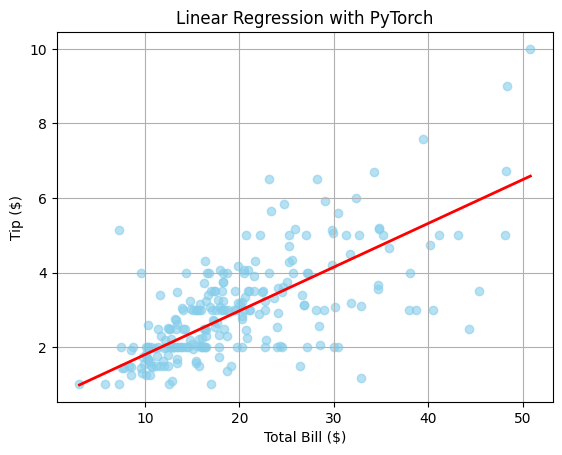

In [6]:
import torch
import torch.nn as nn # nn : neural network(신경망)
import torch.optim as optim # 최적화
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 준비 (Seaborn의 tips 데이터셋)
tips = sns.load_dataset("tips")

# 입력(X): total_bill, 출력(y): tip
# 아래 dtype은 데이터 타입을 float 으로 저장하라는 뜻입니다
X = torch.tensor(tips["total_bill"].values, dtype=torch.float32).reshape(-1, 1)
y = torch.tensor(tips["tip"].values, dtype=torch.float32).reshape(-1, 1)

# 모델 정의 - 선형함수 y = wx + b 하나 생성
model = nn.Linear(1, 1)  # 입력 1개(total_bill), 출력 1개(tip)

# 손실함수 & 옵티마이저
# 옵티마이저 = weight, bias를 변경하는 알고리즘 종류, GD를 사용합니다.
criterion = nn.MSELoss() # MSE 사용
optimizer = optim.SGD(model.parameters(), lr=0.001) # 옵티마이저 = GD, SGD => 확률적 기울기 하강, 전체데이터가 아닌 일부 만 사용해서 손실이 줄어드는 방향으로 조금씩 가중치(w)를 조정

# 학습 루프
for epoch in range(2000): # 점프 2000번~! // epoch : 딥러닝 학습에서 가장 기본적인 학습 단위
    y_hat = model(X) #모델 예측

    loss = criterion(y_hat, y) #로스 계산

    optimizer.zero_grad() #미분 계산 초기화 (미분 Ready), 기울기 누적 방지 why? 이번 학습 스텝(epoch)의 기울기만 계산하기 위해, 이전 step의 기울기 무시
    loss.backward() #미분 계산 수행

    optimizer.step() #GD 점프 1회 (w, b 값이 업데이트 됩니다.)

    if epoch % 400 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f}")

# 학습 결과 출력
print()
print('[학습완료]')
print(f'학습된 가중치(weight): {model.weight.item()}')
print(f'학습된 편향(bias)) : {model.bias.item()}')
print()

# 예측 선 준비
with torch.no_grad():
  x_line = torch.linspace(X.min(), X.max(), 100).reshape(-1, 1)
  y_line = model(x_line)

# 시각화
plt.scatter(X.numpy(), y.numpy(), color='skyblue', alpha=0.6)
plt.plot(x_line.numpy(), y_line.numpy(), color='red', linewidth=2)
plt.title("Linear Regression with PyTorch")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.grid(True)
print()

### 위 소스코드에서 미분 추적기능 ON 안했는데, 미분이 되네요?!
- model = nn.Linear(1, 1) 코드를 실행하면 내부적으로 2개의 파라미터가 생성됩니다.
  - model.weight 텐서
  - model.bias 텐서
- 그리고 위 Tensor 값은 requires_grad = True 옵션으로 생성됩니다.
- **결론적으로 nn.Linear() 함수 수행부터 '미분 추적 기능'이 ON 됩니다.**


# 7. 함수 중첩과 Sequencial Model
- 수학적으로 함수 중첩이라는 말을 먼저 살펴보겠습니다.


$$\huge \left. \begin{aligned} {\color{red}{y_1}} &= Wx + b \\ {\color{blue}{y_2}} &= W{\color{red}{y_1}} + b \end{aligned} \right\} \longrightarrow {\color{blue}{y_2}} = W({\color{red}{Wx + b}}) + b$$

- 수학에서는 한 함수의 결괏값이 다른 함수의 입력값으로 들어오는 것을 함수 중첩이라고 합니다.
- 신경망에서는 "함수 중첩"이라는 용어를 안쓰고, Sequencial(순차적) Model 구조라고 합니다.

### Sequencial Model 언제 쓰죠?
- 우리 썼었어요~. 로지스틱 회귀할 때 사용했습니다.
  - y = sigmoid(ax + b) 기억나시죠?
- PyTorch 에서는 이 Sequencial Model 을 만들기 위한 간결한 문법을 지원합니다.
- 공부시간별 합격 확률을 구하는 로지스틱 회귀 예시를 PyTorch로 만들어보겠습니다.

Epoch   0 | Loss: 2.4648
Epoch 100 | Loss: 0.4315
Epoch 200 | Loss: 0.3290
Epoch 300 | Loss: 0.2706
Epoch 400 | Loss: 0.2335
학습완료



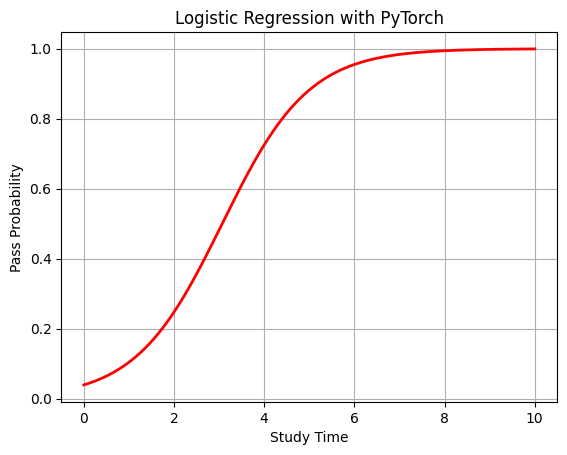

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 공부 시간, pytorch는 행렬(2차원 텐서) 형태로 데이터를 처리하기 때문에 2차원 배열의 형태로 만들어줌
X = torch.tensor([
    [1.0], [2.0], [3.0], [4.0], [5.0], [6.0],
    [2.0], [3.0], [4.0], [5.0], [6.0], [7.0],
    [1.0], [2.0], [3.0], [4.0], [5.0], [6.0],
    [7.0], [8.0], [2.0], [3.0], [4.0], [5.0],
    [6.0], [7.0], [8.0], [9.0], [10.0]
])

# 합격 여부 (0 : 불합격, 1 : 합격), 마찬가지로 2차원텐서 형태
y = torch.tensor([
    [0.0], [0.0], [0.0], [1.0], [1.0], [1.0],
    [0.0], [0.0], [1.0], [1.0], [1.0], [1.0],
    [0.0], [0.0], [0.0], [1.0], [1.0], [1.0],
    [1.0], [1.0], [0.0], [0.0], [1.0], [1.0],
    [1.0], [1.0], [1.0], [1.0], [1.0]
])

# [중요] 아래 모델은 sigmoid(wx + b) 가 됩니다.
model = nn.Sequential(
    nn.Linear(1, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss() # Binary 크로스 엔트로피 로스 펑션
optimizer = optim.SGD(model.parameters(), lr=0.1) # GD 사용, lr = learning rate, 학습률, 점프 얼마나 뛸껀지

for epoch in range(500):
    y_hat = model(X)

    loss = criterion(y_hat, y)

    optimizer.zero_grad() # 초기화
    loss.backward() # 미분 계산

    optimizer.step() # 학습 (w, b 값 업데이트)

    if epoch % 100 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")

print('학습완료')

# 예측 선 준비
with torch.no_grad():
  x_line = torch.linspace(0, 10, 200).reshape(-1, 1)
  y_line = model(x_line)

# 시각화
plt.plot(x_line.numpy(), y_line.numpy(), color='red', linewidth=2)
plt.title("Logistic Regression with PyTorch")
plt.xlabel("Study Time")
plt.ylabel("Pass Probability")
plt.grid(True)
print()

# 8. 함수의 중첩과 활성화 함수로 비선형 구현하기


- y = wx + b와 같은 구조로는 치킨 라인, 고양이 곡선 처럼 비선형을 표현할 수 없었습니다.
  - y = w(w(wx + b) + b) + b .. 와 같이 함수 중첩으로도 비선형을 표현할 수 없었습니다.
- 그런데 활성화 함수와 함수 중첩을 함께 사용하니까, 모든 비선형 곡선을 표현할 수 있습니다.
  - 수학적 원리는 EASY 교안에서 다루지 않습니다.


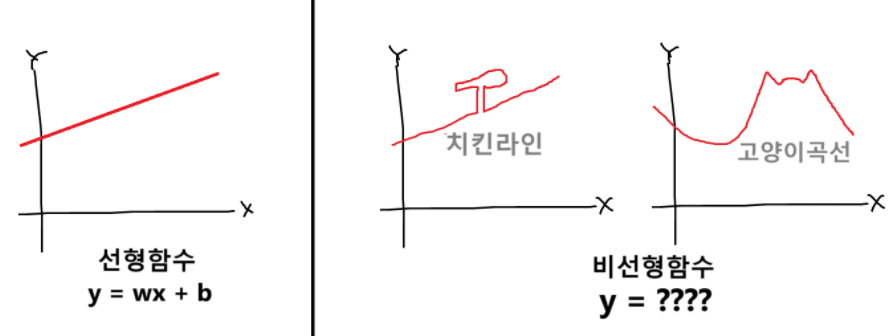

- 우리는 결과만 이해하도록 하겠습니다.
- 활성화 함수는 대표적으로 ReLU (렐루라고 읽습니다. 할렐루야 할때 렐루입니다.) 가 있습니다.
- ReLU 는 단순합니다.
  - 음수는 모두 0으로 바꾼다.
  - 양수는 그대로 사용한다.
- ReLU 는 조건부 수식으로 표현합니다.

$\huge f(x) = \begin{cases}
0, & \text{만약 } x \leq 0 \\
x, & \text{만약 } x > 0
\end{cases}$

- ReLU 함수 자체는 비선형 방정식입니다.
  - 선형 방정식(y = ax + b로 표현될 수 있는 방정식)이 아닌건 다 비선형입니다.
- 수학자에 의해 **비선형 방정식의 중첩으로, 모든 비선형을 나타낼 수 있음**은 1980년대에 증명이 되었습니다.
  - 그리고 비선형 방정식 중에 특히 ReLU는 학습 속도에 되게 좋아요! 라고 제프리힌튼 교수님이 강조하고, 실 사용에 증명했습니다. (2010년)
- 고양이, 치킨곡선 같은 것도, 비선형 방정식 중첩으로 표현할 수 있습니다.
  - 실제 존재하는 곡선이 아니라, 복잡한 형태의 곡선을 가정한 것입니다.
  


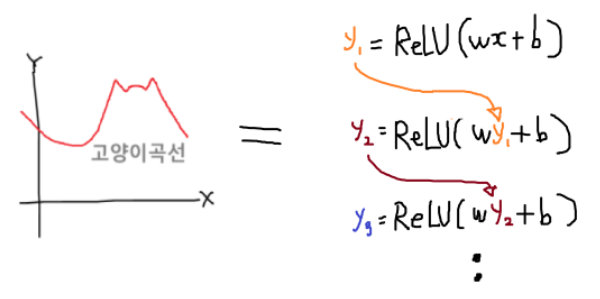

- 신경망 이론에서는 비선형 방정식의 각 단계를 'Layer' 라고 부르기로 했습니다.

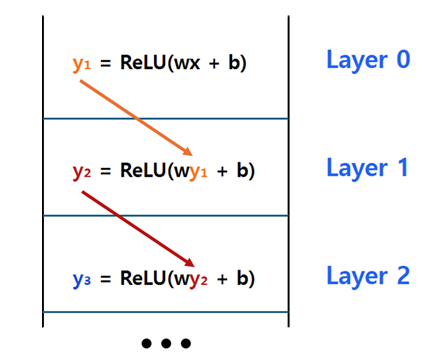

### [참고] 학습 결과 비선형 방정식이 만들어지는 예시

- 비선형 방정식의 중첩으로 고양이 곡선을 한번 만들어보겠습니다.
- 내부 코드는 가볍게 살펴봐주세요.
  - 레이어 개수, 레이어의 입력과 출력 개수, lr, epoch 전부 하이퍼파라미터입니다.

Epoch     0 | Loss: 31.959269
Epoch   500 | Loss: 0.049239
Epoch  1000 | Loss: 0.048380
Epoch  1500 | Loss: 0.056455
Epoch  2000 | Loss: 0.040903
Epoch  2500 | Loss: 0.042605
Epoch  3000 | Loss: 0.052620
Epoch  3500 | Loss: 0.040687
Epoch  4000 | Loss: 0.054392
Epoch  4500 | Loss: 0.057568
Epoch  5000 | Loss: 0.006991
Epoch  5500 | Loss: 0.009983
Epoch  6000 | Loss: 0.004618
Epoch  6500 | Loss: 0.003059
Epoch  7000 | Loss: 0.001865
Epoch  7500 | Loss: 0.017514
Epoch  8000 | Loss: 0.001063
Epoch  8500 | Loss: 0.000940
Epoch  9000 | Loss: 0.000773
Epoch  9500 | Loss: 0.001358



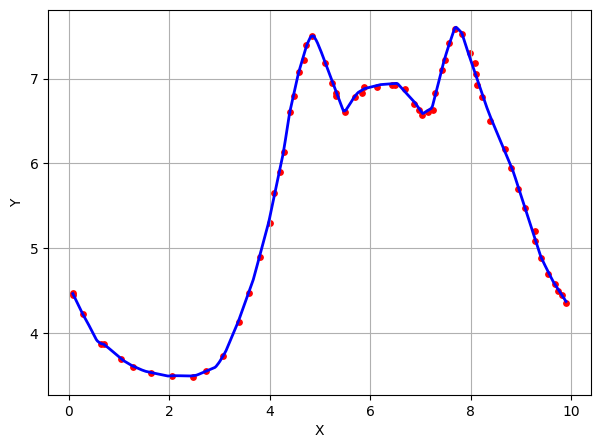

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 고양이 좌표
data = torch.tensor([
    [0.65, 3.87],[0.08, 4.47],[0.08, 4.45],[0.28, 4.22],[0.70, 3.87],
    [1.03, 3.70],[1.28, 3.60],[1.63, 3.53],[2.05, 3.50],[2.48, 3.48],
    [2.73, 3.55],[3.08, 3.73],[3.38, 4.13],[3.58, 4.47],[3.80, 4.90],
    [4.00, 5.30],[4.08, 5.65],[4.20, 5.90],[4.28, 6.13],[4.40, 6.60],
    [4.48, 6.80],[4.58, 7.08],[4.68, 7.22],[4.73, 7.40],[4.85, 7.50],
    [5.10, 7.18],[5.25, 6.95],[5.33, 6.83],[5.33, 6.80],[5.50, 6.60],
    [5.70, 6.78],[5.83, 6.83],[5.88, 6.90],[6.13, 6.90],[6.43, 6.92],
    [6.50, 6.92],[6.70, 6.88],[6.88, 6.70],[6.98, 6.63],[7.03, 6.57],
    [7.30, 6.83],[7.43, 7.10],[7.50, 7.22],[7.58, 7.42],[7.68, 7.58],
    [7.15, 6.60],[7.25, 6.63],[7.83, 7.52],[7.98, 7.30],[8.08, 7.18],
    [8.10, 7.05],[8.13, 6.92],[8.23, 6.78],[8.38, 6.50],[8.68, 6.17],
    [8.80, 5.95],[8.95, 5.70],[9.08, 5.47],[9.28, 5.20],[9.28, 5.08],
    [9.40, 4.88],[9.55, 4.70],[9.68, 4.58],[9.75, 4.50],[9.83, 4.45],
    [9.90, 4.35]
], dtype=torch.float32)

# 입력(X), 출력(y)
X = data[:, [0]]
y = data[:, [1]]

# 모델 정의 (비선형 MLP)
model = nn.Sequential(
    nn.Linear(1, 64), # Layer 0, 입력은 1개, 출력은 64개
    nn.ReLU(),
    nn.Linear(64, 128), # Layer 1, 입력은 64개, 출력은 128개
    nn.ReLU(),
    nn.Linear(128, 128), # Layer 2, 입력은 128개, 출력 128개
    nn.ReLU(),
    nn.Linear(128, 1) # Layer 3, 최종 출력은 1개
)

# 손실함수 & 옵티마이저
criterion = nn.MSELoss()
#optimizer = optim.SGD(model.parameters(), lr=0.01) # GD
optimizer = optim.Adam(model.parameters(), lr=0.005) # 그냥 GD 보다 Adam 이 성능이 더 잘나와요.

# 학습 루프
for epoch in range(10000):
    y_pred = model(X)
    loss = criterion(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.6f}")

# 예측 곡선 생성, 자동미분 비활성화(손실을 계산할 필요가 없기 때문, 기울기를 쓸일이 없음)
with torch.no_grad():
    x_line = torch.linspace(X.min(), X.max(), 400).reshape(-1, 1)
    y_line = model(x_line)

# 시각화
plt.figure(figsize=(7,5))
plt.scatter(X.numpy(), y.numpy(), color='red', s=15)
plt.plot(x_line.numpy(), y_line.numpy(), color='blue', linewidth=2)
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
print()


- 다음은 치킨 곡선입니다.
  - 치킨곡선의 특징은 한 x에 여러개 y가 존재하는 차트입니다.
  - 따라서 MLP로 표현할 수 없고 다음과 같이 그릴 수 있습니다.
    - 입력 : t 시간
    - 출력 : [x, y] 좌표

Epoch     0 | Loss: 24.883440
Epoch  1000 | Loss: 0.813539
Epoch  2000 | Loss: 0.419906
Epoch  3000 | Loss: 0.215039
Epoch  4000 | Loss: 0.081454
Epoch  5000 | Loss: 0.046156
Epoch  6000 | Loss: 0.034450
Epoch  7000 | Loss: 0.024740
Epoch  8000 | Loss: 0.017669
Epoch  9000 | Loss: 0.013798
Epoch 10000 | Loss: 0.011982
Epoch 11000 | Loss: 0.011207
Epoch 12000 | Loss: 0.010833
Epoch 13000 | Loss: 0.010623
Epoch 14000 | Loss: 0.010450



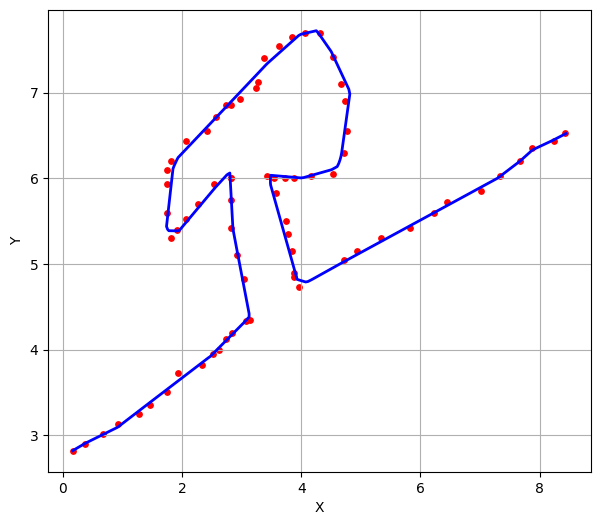

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 치킨 좌표, 좌표는 이었을때 치킨 모양이 되도록 직접 지정함
data = torch.tensor([
    [0.17, 2.82], [0.37, 2.90], [0.67, 3.02], [0.92, 3.13], [1.27, 3.25],
    [1.47, 3.35], [1.74, 3.50], [1.94, 3.73], [2.34, 3.82], [2.52, 3.95],
    [2.62, 4.00], [2.74, 4.13], [2.84, 4.20], [3.07, 4.33], [3.14, 4.35],
    [3.04, 4.83], [2.92, 5.10], [2.82, 5.42], [2.82, 5.75], [2.82, 6.00],
    [2.82, 6.00], [2.54, 5.93], [2.27, 5.70], [2.07, 5.53], [1.92, 5.40],
    [1.82, 5.30], [1.74, 5.60], [1.74, 5.93], [1.74, 6.10], [1.82, 6.20],
    [2.07, 6.43], [2.57, 6.72], [2.74, 6.85], [2.82, 6.85], [2.97, 6.92],
    [3.24, 7.05], [2.42, 6.55], [3.27, 7.13], [3.37, 7.40], [3.62, 7.55],
    [3.84, 7.65], [4.07, 7.70], [4.32, 7.70], [4.54, 7.42], [4.67, 7.10],
    [4.74, 6.90], [4.77, 6.55], [4.72, 6.30], [4.54, 6.05], [4.17, 6.03],
    [3.87, 6.00], [3.72, 6.00], [3.54, 6.00], [3.42, 6.03], [3.57, 5.83],
    [3.74, 5.50], [3.77, 5.35], [3.84, 5.15], [3.87, 4.90], [3.87, 4.85],
    [3.97, 4.73], [4.72, 5.05], [4.94, 5.15], [5.34, 5.30], [5.82, 5.42],
    [6.22, 5.60], [6.44, 5.72], [7.02, 5.85], [7.34, 6.03], [7.67, 6.20],
    [7.87, 6.35], [8.24, 6.43], [8.42, 6.53]
], dtype=torch.float32)

# 입력 = t, 출력 = (x, y)
t = torch.linspace(0, 1, len(data)).reshape(-1, 1)
X_target = data  # 출력 목표: (x, y)

# 모델 정의
model = nn.Sequential(
    nn.Linear(1, 128), # layer 0, 첫 입력은 1개 (t)
    nn.ReLU(),
    nn.Linear(128, 128), # Layer 1
    nn.ReLU(),
    nn.Linear(128, 128), # Layer 2
    nn.ReLU(),
    nn.Linear(128, 2) # Layer 3, 최종 출력은 2개 (x, y)
)

# 학습 설정
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 학습
for epoch in range(15000):
    X_pred = model(t)
    loss = criterion(X_pred, X_target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.6f}")


# 예측 선 생성
with torch.no_grad():
    t_dense = torch.linspace(0, 1, 400).reshape(-1, 1)
    pred_curve = model(t_dense)

# 시각화
plt.figure(figsize=(7,6))
plt.scatter(X_target[:,0], X_target[:,1], color='red', s=15)
plt.plot(pred_curve[:,0], pred_curve[:,1], color='blue', linewidth=2)
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
print()

### 왜 회귀선으로 그림을 그렸나요?
- ReLU 같은 비선형 방정식의 중첩을 모델로 사용하면, 비선형 방정식들을 모사할수 있다는 것을 입증하기 위함입니다.

# 9. 신경망 역사 시간
- 이번 챕터는 역사가 참 많은 것 같습니다.
- 머신러닝은 여러가지가 있는데.. 이중 신경망에 대해서만 말해볼겁니다.


### 퍼셉트론 등장 (1958년)

- 1958년 Perceptron (퍼셉트론) 신경망 모델의 시작이었습니다.
  - 1개의 선형함수
  - 1개의 활성화함수 (이때는 비선형 활성화 함수가 아닙니다.)
  - 학습 개념 도입

- 당시 생물학 연구가 활발한 시기라, 두뇌의 뉴런 동작을 보고 수학적인 분류기를 고안한 겁니다.
  - 새가 날라다니는 것 보고, 비행기를 고안한것 처럼요..
  - 퍼셉트론이 등장하기 전에도 "선형분류기"가 있었는데요..
  - 선형분류기에 학습 개념(Weight, bias 업데이트) 을 추가한 것이 바로 퍼셉트론입니다.

<br/>

### MLP (Multi Layer Perceptron) 등장 (1986년)
- Multi Layer Perception... MLP 가 등장했습니다.
- 퍼셉트론을 중첩한 모델을 사용하고, 학습은 GD를 사용합니다.
- 멀티 레이어에서 GD에 필요한 미분값을 계산하는 방법인 **Backpropagation(백프라퍼게이션) 알고리즘**이 만들어졌습니다.
  - PyTorch에서는 loss.backward()를 호출하면 백프라퍼게이션 알고리즘으로 미분 계산이 이뤄집니다.
  - 백프라퍼게이션 알고리즘의 상세 내용은 EASY 교안에서 생략합니다~.
  - "멀티레이어에서 GD에 필요한 미분 계산 방법" 으로 암기해주세요.


### 딥러닝
- 딥러닝이란?
  - 사람이 Feature를 선택해서 입력을 넣지 않고, 모델이 스스로 Feature를 정하고 학습하는 신경망 입니다.
  - 예시
    - 사진에서 사람 얼굴 테두리 선만 전처리해서 모델 입력으로 넣는 것이 아니라, 그냥 사진 통짜로 넣는 모델 (CNN)
    - 음성의 주파수만 추출해서 입력을 넣는 것이 아니라, 그냥 음성파일 통짜로 넣는 모델 (RNN)
  - 즉, 사람이 Feature를 설계하지 않아도, 모델이 스스로 Feature까지 찾아내는 학습을 "딥러닝" 이라고 부릅니다.
- 다음과 같은 특징을 갖습니다.
  - 깊은 Layer를 갖는 경우가 많습니다.
  - 데이터가 대량으로 필요한 경우가 많습니다.
  - 대규모 연산이 필요한 경우가 많습니다. (<--- 딥러닝부터는 우리는 GPU 써서 수업할겁니다.)
- 기준이 모호합니다.
  - 사람들이 부르는 칭호 같은거라 기준이 모호합니다.
    - 예시 : 저 사람은 탑스타야 (탑스타의 기준??)
  - 정확히 몇개 Layer부터 딥러닝입니까? : 정해진 Layer 수 없습니다.
  - Feature를 조금 주면 딥러닝이 아닙니까? : 딥러닝일수도 아닐수도 있습니다. 정해진바는 없습니다.
  - 그럼 제가 딥러닝이라고 하면 딥러닝입니까? : 특징을 자동으로 찾아내기만 하면 맞습니다.

# 10. MNIST 데이터 셋 소개
- MNIST : Modified National Institute of Standards and Technology database
  - 한글 번역 : 수정된 미국 국립표준기술원 데이터베이스
- 그냥 손글씨 숫자 이미지 자료입니다.
  - 글자당 28 x 28 픽셀
  - 0 ~ 9 숫자
  - 검은색 배경에 밝은 색 글씨

<br/>

- 데이터가 아니라 데이터 셋 입니다.
  - 데이터 셋 = 데이터 + 정답 값 (Label) 입니다.
  - MNIST 데이터 셋은, 손글씨 이미지랑, 어떤 숫자인지 정답이 함께 들어있습니다.

<br/>

- MNIST는 전설의 레전드 실습자료 입니다.
  - for문 배울 때 '별찍기' 문제와 같은 느낌이죠.

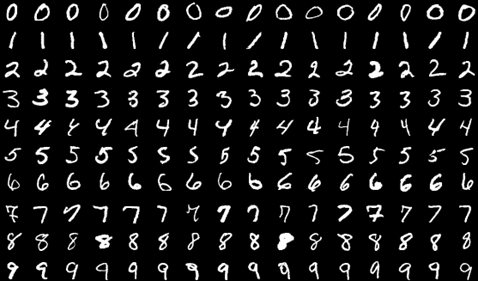

- 숫자 하나를 확대해보겠습니다.
  - 28 x 28 픽셀이니까 총 784 칸으로 구성된 이미지
  - 각 칸마다 명도값이 적혀있습니다. (0 ~ 255, 0 이면 검은색, 255는 흰색)

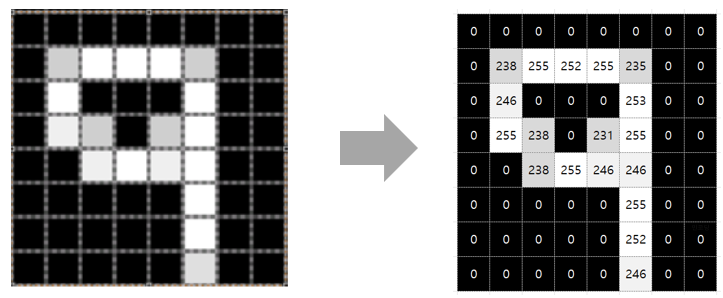

### 직접 데이터 셋 을 구경해봅시다.
- 따로 다운로드 안받아도 됩니다. 구글 코랩이 기본적으로 제공합니다.


- mnist_train_small.csv
  - 훈련용 데이터
  - 20,000 - 1 = 19,999개 레코드
  - 첫 컬럼은 정답이고, 나머지 784는 픽셀 값 입니다.
- mnist_test.csv
  - 모델 성능 평가용 데이터
  - 10,000 - 1 = 9,999개 레코드

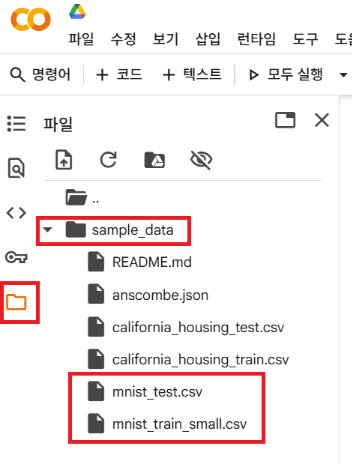

- 대부분 값이 0 이 적혀있을 텐데, 배경색이 값이 0(검은색) 이라 그렇습니다.

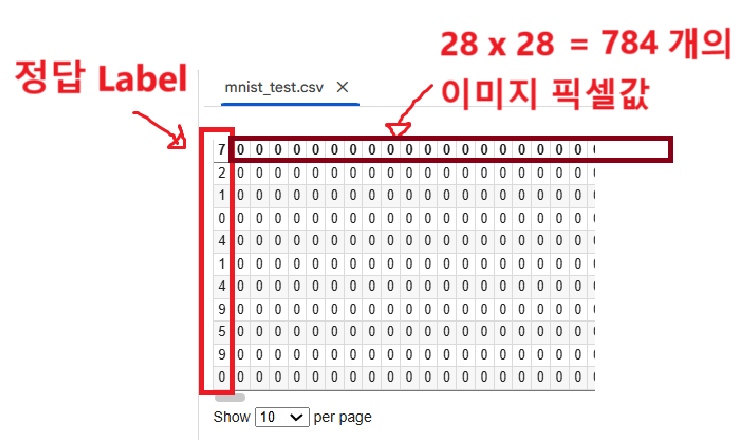

- 아래 이미지를 출력하는 코드는 다음과 같습니다.
  - Data Frame의 Series(Column) 별로 pytorch의 tensor로 변환합니다.
    - Label이 적혀있는 0번 Series ==>  1차원 텐서로 변환
    - 이미지가 적혀있는 1번 ~ 끝번 Series ==> 2차원 텐서로 변환
  - 이미지 3개만 출력해봅시다.

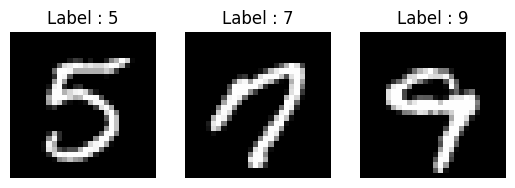

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import load_digits

# MNIST train csv 로드 (19,999개)
# PyTorch 에는 csv 파일 읽는 기능이 없어서, Pandas를 사용했습니다.
test_df = pd.read_csv("sample_data/mnist_train_small.csv")

# 0번 Series(Column)에는 약 19,999개 Label이 있습니다.
labels = torch.tensor(test_df.iloc[:, 0].values) # 결과 : 1차원 텐서 (9,999)

# 1 ~ Last번 Series(Column)에는 약 19,999개 이미지값이 있습니다.
images = torch.tensor(test_df.iloc[:, 1:].values) # 결과 : 2차원 텐서 (9,999 x 784)

# 3개 이미지 출력
for i in range(3):
  # 784개 값을 [28 x 28] 행렬로 변환
  record = images[i].reshape(28, 28)

  plt.subplot(1, 3, i + 1)

  #imshow = image show, matplot의 이미지 출력 기능
  plt.imshow(record, cmap="gray")
  plt.title(f'Label : {labels[i].item()}')
  plt.axis("off")

#### MNIST 데이터 셋으로 뭘 할까요?
- 우리는 MNIST 데이터셋을 이용한 숫자 분류기를 만들어볼겁니다.
  - PyTorch의 Data Loader를 사용해볼겁니다.
  - 3 Layer로 구성된 MLP 모델을 만들겁니다.
- 이 실습을 위해 필요한 내용들을 하나씩 학습해보시죠.

# 11. PyTorch의 DataLoader 이해하기


- 딥러닝을 다룰 때 Data Loader는 앞으로 계속 쓰게 될것이니, 조금 자세히 이해를 하도록 하겠습니다.

- 데이터셋을 랜덤하게 섞어서 학습시키면 학습이 더 잘됩니다.
  - 예시
    - 고등어만 100 만 마리 학습시키면, 모델이 특징을 잘못 잡습니다.
    - 고등어랑 갈치랑 섞어가면서 학습시면, 모델이 비교하면서 특징을 더 잘잡습니다.
    - 역시 수학적 증명은 생략 ^^

<br/>

- 데이터를 랜덤하게 선택하는 것을 코딩하는 건, 어렵지 않지만 번거로운 일입니다.
  - 문제 : 1 ~ 30 번을 랜덤한 순서대로 하나씩 뽑아주세요. 같은 수를 뽑으면 안됩니다.
  - 구현 방법
    1. 1 ~ 30 까지 순차적으로 적은 List 준비
    2. 랜덤 값 2개 만들어서 SWAP 반복
    2. 만들어진 List 순서대로 값 하나씩 뽑기

In [11]:
import random

order = list(range(1, 31)) # [1, 2, 3, 4, .... , 29, 30]

# 랜덤한 위치 두 개를 골라 SWAP을 여러 번 수행
for _ in range(100):
    a = random.randint(0, 29)
    b = random.randint(0, 29)
    #swap
    order[a], order[b] = order[b], order[a]

# 결과 확인
for n in order:
    print(n, end = ' ')

5 3 27 11 9 2 25 12 19 22 8 21 13 28 23 15 6 16 14 30 10 29 1 26 24 4 7 18 17 20 

- DataLoader는 위 코드 보다 더 빠른 알고리즘으로 만들어져있습니다.
- DataLoader를 이용하면 랜덤한 순서대로 이미지를 하나씩 선정할 수 있습니다.
  - **DataLoader의 원래 목적은 엄청나게 거대한 데이터 전체를 한꺼번에 읽지 않고, 조금씩 읽어오는게 목적입니다.**
  - 또한 여러 CPU를 이용해서 여러 데이터를 한꺼번에 불러오는 기능도 있습니다.
- **우리 MNIST 실습에는 단순히 "랜덤한 이미지 지정"을 위해 사용할겁니다.**
  - 사실은.. csv 파일 자체에 랜덤한 순서로 이미지가 저장되어있어서, 큰 의미는 없긴해요.

  

### PyTorch의 DataLoader가 원하는 자료 형태
- DataLoader가 원하는 입력 형태가 있습니다.
- (입력데이터, Label) 형태로 된 Tuple들의 List 형태를 입력으로 주면 됩니다.

In [12]:
input = ["TigerStar", "J-Dragon", "이노"]
label = ["범성", "자룡", "인호"]

print(list(zip(input, label)))

[('TigerStar', '범성'), ('J-Dragon', '자룡'), ('이노', '인호')]


- batch 는 몇 개의 데이터 셋 뭉치를 몇개씩 모델에 입력할지, 모델의 입력 단위입니다.
  - 모델에 이미지 한 장씩 입력하고 싶으면 batch_size = 1 로 하면 됩니다.
  - 모델에 이미지 세 장씩 입력하고 싶으면 batch_size = 3 로 하면 됩니다.

In [13]:
import pandas as pd
import torch
from torch.utils.data import DataLoader

train_df = pd.read_csv("sample_data/mnist_train_small.csv")

# X = 픽셀(784), y = 정답 Label
images = torch.tensor(train_df.iloc[:, 1:].values, dtype=torch.float32)
labels = torch.tensor(train_df.iloc[:, 0].values, dtype=torch.long)

# Dataset 만들기 (입력, 정답 한 쌍씩)
train_dataset = list(zip(images, labels))

# batch는 모델에 입력할 데이터 개수입니다.
# [중요] batch_size를 바꾸어가면서 batch를 이해해주세요.
b_size = 5
train_loader = DataLoader(train_dataset, batch_size=b_size, shuffle=True) # 랜덤 = True

for X_batch, y_batch in train_loader:
  print(f'모델에 입력 데이터 크기 : {X_batch.shape}')
  print(f'모델 맞춰야하는 Label 결과 : {y_batch}')
  break




모델에 입력 데이터 크기 : torch.Size([5, 784])
모델 맞춰야하는 Label 결과 : tensor([0, 7, 0, 2, 1])


- batch 단위는 모델에 입력할 데이터 묶음의 개수입니다.
  - 수학적으로 y = wx + b 에서 x에 여러 이미지를 동시에 입력으로 넣을 수 있습니다.
    - 이미지 1장 : (1, 784) 행렬
    - 이미지 3장 : (3, 784) 행렬
  
  - 이때 각각 이미지에 해당하는 w, b 를 따로 사용하지 않고, 모든 이미지가 공통된 w, b 를 사용합니다.
    - 여기에 대한 수학식은 생략합니다. ^^
    - 이로 인해 연산량은 이미지 수 만큼 배로 더 들긴하지만.. 병렬처리 덕분에 성능 저하가 별로 없습니다.

# 12. MNIST 데이터 셋으로, 숫자분류기 코드 분석하기
- 거의 다 왔습니다. 마지막 Step 입니다.
- 숫자분류기 코드를 리뷰해보겠습니다.

In [14]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

#=============================================================
# 1. 데이터 준비 (csv -> data loader에 입력 해두기 까지)
#=============================================================
train_df = pd.read_csv("sample_data/mnist_train_small.csv")

# 전처리를 안하니까 가끔씩 학습 실패해서... / 255로 스케일링이 필요했습니다. (0 ~ 1 값으로 정규화)
X_train = torch.tensor(train_df.iloc[:, 1:].values, dtype=torch.float32) / 255.0
y_train = torch.tensor(train_df.iloc[:, 0].values, dtype=torch.long)

# Data Loader 세팅 완료
train_dataset = list(zip(X_train, y_train))
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

#=============================================================
# 2. 모델 준비
#=============================================================
# Layer의 개수, 중간 Layer의 입력과 출력의 개수는 모두 하이퍼파라미터 입니다. 왜 256 이고 128 이냐?? 2의 거듭제곱 단위/ 적당한표현력, 경험적인 수치..
model = nn.Sequential(
    nn.Linear(784, 256), # 한 batch당 입력과 출력 개수를 적는 것을 잊지마세요.
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10) # 최종 출력값은 10개 입니다. '0' ~ '9' 의 점수 값이 나옵니다.
)

#=============================================================
# 3. Loss & Optimizer (Adam)
#=============================================================
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#=============================================================
# 4. 학습
#=============================================================
epochs = 5
for epoch in range(epochs):
    total_loss = 0
    for X_batch, y_batch in train_loader:

        outputs = model(X_batch) # 예측

        loss = loss_fn(outputs, y_batch) # loss 계산 (softmax도 함께 수행함)

        optimizer.zero_grad() # 미분 엔진 초기화
        loss.backward() # 미분 계산
        optimizer.step() # 파라미터 업데이트

        total_loss += loss.item() # Loss 누적

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

#=============================================================
# 5. 학습 완성된 파라미터들, 파일로 저장
#=============================================================
# 학습 결과로 찾아낸 파라미터 값들을 파일로 저장합니다.
# .pth 확장자로 저장합니다. (pth = pytorch 약어)
torch.save(model.state_dict(), "model.pth")


Epoch 1/5, Loss: 0.4743
Epoch 2/5, Loss: 0.1951
Epoch 3/5, Loss: 0.1289
Epoch 4/5, Loss: 0.0940
Epoch 5/5, Loss: 0.0655


- 저장된 파일은 '새로고침' 버튼을 눌러 확인할 수 있습니다.

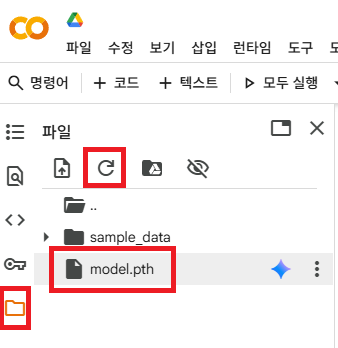

### 만들어진 모델, 불러와서 추론해보기
- 총 4,000시간이 걸려 학습을 했다고 가정합니다. ^^
- Application에서는 이 모델을 가져다, 추론용으로 사용하면 됩니다.
  - 아래 코드는 실행할 때마다 입력 데이터가 랜덤하게 선택되어, 결과가 달라져요.

입력 이미지


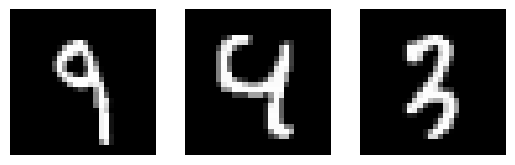


모델 추론 결과 : tensor([9, 4, 3])


In [15]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

#=============================================================
# 1. 모델 구조 정의 (학습할 때랑 똑같아야 함)
#=============================================================
model = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

#=============================================================
# 2. 모델 불러오기
#=============================================================
model.load_state_dict(torch.load("model.pth"))  # 저장했던 파일 로드


#=============================================================
# 3. 테스트 데이터 준비
#=============================================================
test_df = pd.read_csv("sample_data/mnist_test.csv")

# 학습했던 것과 정규화 똑같이 해주기
X_test = torch.tensor(train_df.iloc[:, 1:].values, dtype=torch.float32) / 255.0
y_test = torch.tensor(test_df.iloc[:, 0].values, dtype=torch.long)

# DataLoader 준비 완료
test_dataset = list(zip(X_test, y_test))
test_loader = DataLoader(test_dataset, batch_size=3, shuffle=True) # batch = 3 장씩

#=============================================================
# 4. 모델에 입력 데이터 이미지 3장 선택
#=============================================================
images = None
for X_batch, y_batch in test_loader:
  images = X_batch
  break

# 입력할 이미지 출력
print('입력 이미지')
for i in range(3):
    plt.subplot(1, 3, i+1)
    record = images[i].reshape(28, 28);
    plt.imshow(record, cmap="gray")
    plt.axis("off")
plt.show()
print()

#=============================================================
# 5. 추론하기!
#=============================================================
with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1) # 10개의 output 값중 가장 큰 값의 index 찾기
    print(f'모델 추론 결과 : {preds}')



### 주요 소스코드 1 : 모델 학습

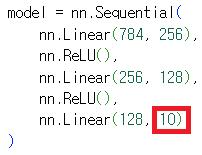

- 출력값을 보면 10 개의 Output이 있습니다.
- Output 값은 다음과 같습니다.
  - y0 : 이미지가 숫자 0 일것 같은 정도를 나타내는 점수
  - y1 : 이미지가 숫자 1 일것 같은 정도를 나타내는 점수
  - y2 : 이미지가 숫자 2 일것 같은 정도를 나타내는 점수
  - ...
  - y9 : 이미지가 숫자 9 일것 같은 정도를 나타내는 점수

- 이 점수의 범위는 정해진게 없습니다. 엄청 작거나 엄청 클수도 있습니다.
  - 수식의 출력 값이예요. 학습 시도중인 w, b 에 따라 값이 결정되죠.

### 주요 소스코드 2 : Loss 계산하기

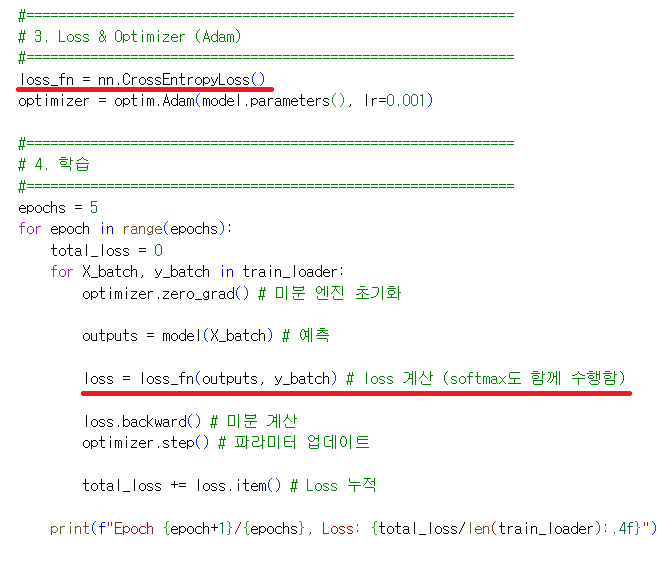

- 모델에서 출력 결과로 0 ~ 9 까지 점수를 획득했습니다.
  - loss = loss_fun(outputs, y_batch) 에서 outputs 변수에 10개의 점수가 들어있습니다.
- 각 점수를 비율에 맞게 확률로 변경합니다. (SoftMax라는 수식을 적용하면 계산할 수 있습니다.)
- 10개의 확률 값중 Max 확률 값을 찾아냅니다.
- 숫자 1에 대한 확률 값이 나왔으니, 오차를 계산할 수 있습니다.
  - 정답은 숫자 1 = 100%
  - 예측값은 숫자 1 = 89%
  - Cross Entropy 함수에 정답과 예측값을 집어넣으면, Loss 값을 계산할 수 있습니다. (수식은 생략)

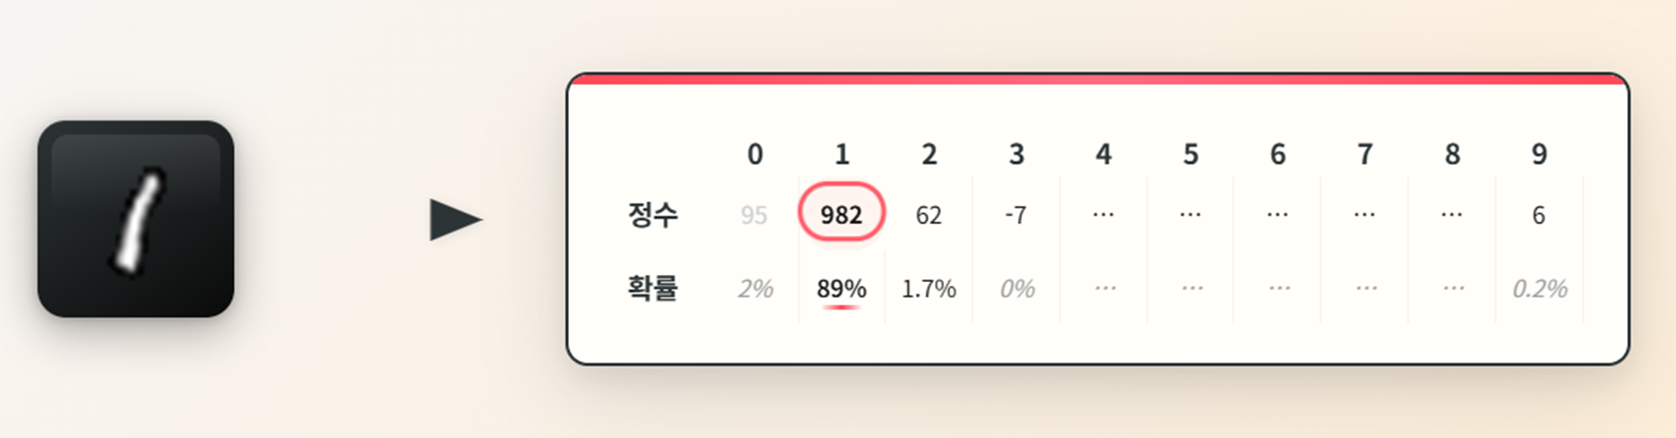

# 13. 끝으로
- 이번 챕터도 고생 많으셨습니다.
- 이번 시간에는 신경망에 대한 역사를 가볍게 살펴봤습니다.
  - 퍼셉트론, MLP, 신경망이 무엇인지 공부했습니다.
  - MLP로 MNIST 데이터셋을 이용한 숫자분류기 코드를 리뷰했습니다.
- 기쁜 소식이 있습니다.
  - EASY 교안 중에서.. 이번 챕터가 가장 어려운 내용이었습니다.
  - (다음 챕터부터 난이도가 내려간다는 뜻입니다.)
- 아시겠지만, AI 학습 내용은 총 3개로 분류될 수 있습니다.

### Easy 자료 (강사님 자료)
- AI를 처음 공부하는 분들을 위해 만들어져있습니다.
- 내용을 모두 이해해야합니다! **강사님의 도움을 적극적으로 받아주세요.**

### 실습 / 과제 자료 (업스테이지 자료)
- AI를 공부해본 경험자 위주로 만들어져있습니다.
- 퍼즐조각을 모은다는 생각으로 공부해주세요!. **GPT의 도움을 적극적으로 받아주세요.**

### 교수님 강의
- 국내 최고의 AI 교수님들의 강의가 시작됩니다.
- 최대한 내용을 이해해봅시다.